## Import The Libraries

In [1]:
!pip install ultralytics

In [2]:
import os
import yaml
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [3]:
class Sys:
    EPOCHS = 40
    BATCH_SIZE = 32
    SEED = 6
    LEARNING_RATE = 0.001
    OPTIMIZER = "Adam"
    TRAIN_IMAGES = "dataset/train/images"
    VALID_IMAGES = "dataset/valid/images"
    TEST_IMAGES = "dataset/test/images"
    OUTPUT_DIR = "ft_models"
    NUM_SAMPLES = 16  # Number of random images for visualization

In [4]:
data_config = {
    "train": Sys.TRAIN_IMAGES,
    "val": Sys.VALID_IMAGES,
    "test": Sys.TEST_IMAGES,
    "nc": 1,  # Number of classes
    "names": ["Brain_Tumor"],  # Class names
}

In [5]:
yaml_file_path = "temp_data.yaml"
with open(yaml_file_path, "w") as file:
    yaml.dump(data_config, file)


In [6]:
def visualize_images(image_folder, num_samples=16):
    image_files = glob(f"{image_folder}/*")
    selected_images = random.sample(image_files, num_samples)
    plt.figure(figsize=(12, 10))
    for i, img_path in enumerate(selected_images):
        plt.subplot(4, 4, i + 1)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

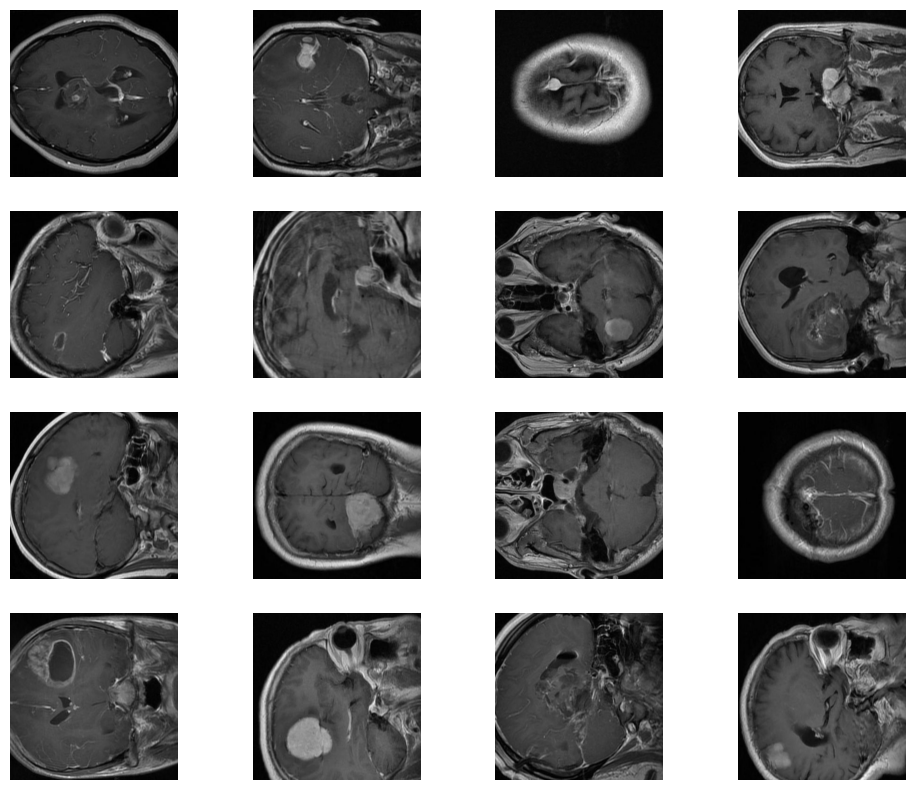

In [7]:
visualize_images(Sys.TRAIN_IMAGES)

In [8]:
model = YOLO("yolov8m.pt")  # Pretrained YOLOv8 model

In [ ]:
model.train(
    data=yaml_file_path,
    seed=Sys.SEED,
    epochs=Sys.EPOCHS,
    lr0=Sys.LEARNING_RATE,
    optimizer=Sys.OPTIMIZER,
    project=Sys.OUTPUT_DIR,
    name="brain_tumor_detection",
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.3.58 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.55 🚀 Python-3.12.3 torch-2.5.1+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=temp_data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=ft_models, name=brain_tumor_detection2, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=6, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=N

E0000 00:00:1736373006.853522    5310 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736373006.877769    5310 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

train: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/train/labels.cache... 1054 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1054/1054 [00:00<?, ?it/s]
val: Scanning /home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/kidney_stone_detection/using_yolo/dataset/valid/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100%|██████████| 123/123 [00:00<?, ?it/s]

Plotting labels to ft_models/brain_tumor_detection2/labels.jpg... 


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      42/50         0G      1.623     0.7546      1.097         33        640: 100%|██████████| 66/66 [28:19<00:00, 25.75s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:55<00:00, 13.95s/it]

                   all        123        325       0.78      0.709      0.735      0.304



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      43/50         0G      1.562     0.7237      1.085         29        640:  27%|██▋       | 18/66 [07:46<21:55, 27.40s/it]

In [9]:
# Cleanup the temporary YAML file if needed
import os
os.remove(yaml_file_path)

In [10]:
# Save the trained model for future use
trained_model_path = f"{Sys.OUTPUT_DIR}/kidney_stone_detection/weights/best.pt"
model_trained = YOLO("ft_models/brain_tumor_detection8/weights/best.pt")

In [11]:
def stone_detection(img_path, model, save_path=None):
    img = cv2.imread(img_path)  # Load image
    results = model(img)  # Perform inference
    detect_img = results[0].plot()  # Add bounding boxes to the image

    if save_path:
        cv2.imwrite(save_path, detect_img)  # Save the output image
    return cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)  # Convert for display

In [12]:
test_images_path = Sys.TEST_IMAGES
test_images = os.listdir(test_images_path)
selected_images = random.sample(test_images, Sys.NUM_SAMPLES)

In [13]:
output_dir = "predicted_images"
os.makedirs(output_dir, exist_ok=True)


0: 544x640 1 Kidney_Stone, 562.3ms
Speed: 6.2ms preprocess, 562.3ms inference, 0.9ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 386.2ms
Speed: 2.4ms preprocess, 386.2ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 414.3ms
Speed: 1.5ms preprocess, 414.3ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 391.2ms
Speed: 3.6ms preprocess, 391.2ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 4 Kidney_Stones, 343.2ms
Speed: 1.9ms preprocess, 343.2ms inference, 0.8ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Kidney_Stones, 403.6ms
Speed: 4.7ms preprocess, 403.6ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 398.1ms
Speed: 2.0ms preprocess, 398.1ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 352.2ms
Speed: 3.1ms preprocess,

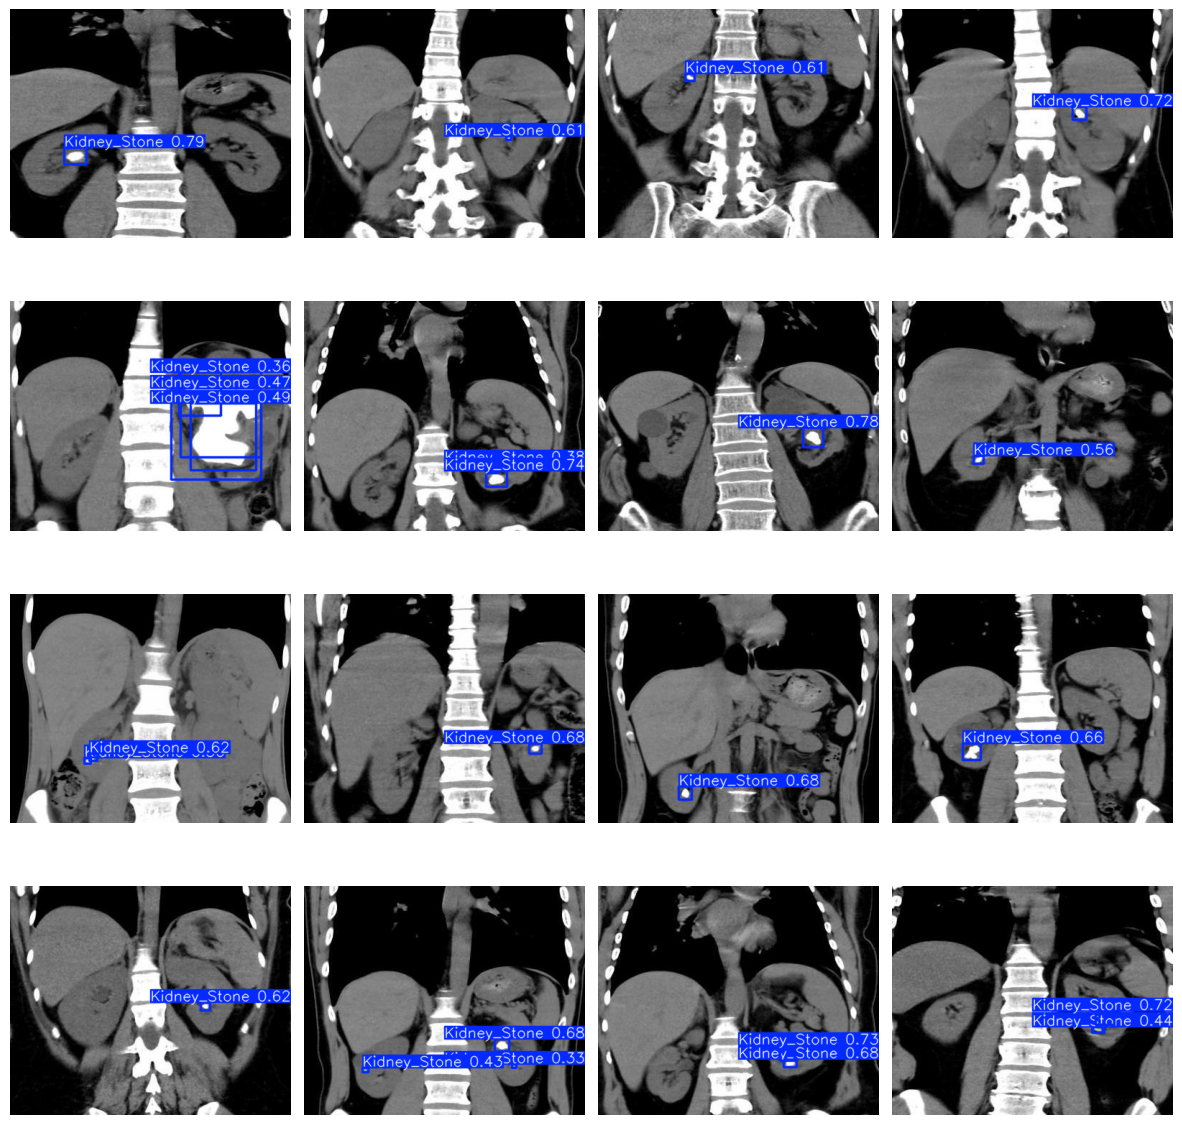

In [14]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 15))
for i, img_file in enumerate(selected_images):
    row_idx = i // 4
    col_idx = i % 4
    img_path = os.path.join(test_images_path, img_file)
    save_path = os.path.join(output_dir, f"predicted_{img_file}")
    detect_img = stone_detection(img_path, model_trained, save_path=save_path)
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis("off")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [15]:
def evaluate_model(model_path, test_images_path):
    model = YOLO(model_path)  # Load trained model
    image_files = glob(f"{test_images_path}/*.jpg")
    
    y_true = []  # True labels
    y_pred = []  # Predicted labels

    for img_path in image_files:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get predictions
        results = model(img)

        # Assuming one class, process the predictions for label assignment
        for result in results:
            if result.boxes.shape[0] > 0:
                y_pred.append(1)  # Predicted kidney stone
            else:
                y_pred.append(0)  # No kidney stone

        # Add ground truth label from filename or annotations
        # (Modify this logic based on how ground truths are stored)
        true_label = 1 if "kidney_stone" in img_path else 0
        y_true.append(true_label)

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print("Confusion Matrix:")
    print(cm)
    print("\nAccuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Kidney Stone", "Kidney Stone"]))

    return cm, acc

In [16]:
model_path = "ft_models/kidney_stone_detection8/weights/best.pt"
test_images_path = Sys.TEST_IMAGES
conf_matrix, accuracy = evaluate_model(model_path, test_images_path)


0: 544x640 2 Kidney_Stones, 410.9ms
Speed: 2.9ms preprocess, 410.9ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 361.9ms
Speed: 1.6ms preprocess, 361.9ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Kidney_Stones, 361.5ms
Speed: 2.1ms preprocess, 361.5ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 346.8ms
Speed: 1.7ms preprocess, 346.8ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 356.2ms
Speed: 2.0ms preprocess, 356.2ms inference, 1.1ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 1 Kidney_Stone, 365.4ms
Speed: 1.6ms preprocess, 365.4ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 2 Kidney_Stones, 354.4ms
Speed: 1.7ms preprocess, 354.4ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 640)

0: 544x640 6 Kidney_Stones, 396.8ms
Speed: 1.8ms preproces

/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/huzbntu/Stuff/cui/F/Eisha/fyp/doc-link-fyp/ml_models/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` para

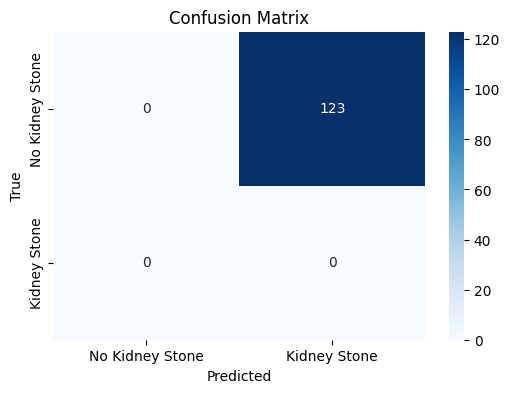

In [17]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Kidney Stone", "Kidney Stone"], yticklabels=["No Kidney Stone", "Kidney Stone"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()